In [1]:
import sys
sys.path.append('..')
import glob
import importlib
import sys




import numpy as np
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, detrend
import matplotlib.pyplot as plt

from src.config import FS, STIM_ONSET, CH_NAMES, TARGET_FREQS , WINDOW_SAMPLES

from src.FBCCA import  load_subject, preprocess_trial , generate_reference_signals , cca_score, predict_fbcca, evaluate_subject_fbcca

ImportError: cannot import name 'FB_BANDS' from 'src.config' (c:\Users\Luchitha\Documents\BCI\SSVEP\notebooks\..\src\config.py)

In [ ]:
import importlib
import src.FBCCA
importlib.reload(src.FBCCA)
from src.FBCCA import evaluate_subject_fbcca

In [ ]:
file = r"C:\Users\Luchitha\Documents\BCI\SSVEP\data\s1.mat"

In [ ]:
eeg = load_subject(file)

print("EEG shape:", eeg.shape)

EEG shape: (12, 8, 1114, 15)


In [ ]:
refs = generate_reference_signals(TARGET_FREQS, WINDOW_SAMPLES, FS)

In [ ]:
# OPTIONAL: select occipital channels (UPDATE THIS!)
# Example: Oz, O1, O2 → indices depend on dataset
use_channels = None  

# Try with rejection threshold
accuracy = evaluate_subject_fbcca(
    eeg,
    use_channels=use_channels
    
)


accuracy

(0.127777777770679,
 array([1.        , 0.        , 0.        , 0.53333333, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ]),
 array([[15,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [15,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [13,  0,  0,  2,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 7,  0,  0,  8,  0,  0,  0,  0,  0,  0,  0,  0],
        [14,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
        [13,  0,  0,  2,  0,  0,  0,  0,  0,  0,  0,  0],
        [14,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
        [13,  0,  0,  2,  0,  0,  0,  0,  0,  0,  0,  0],
        [13,  0,  0,  2,  0,  0,  0,  0,  0,  0,  0,  0],
        [15,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [14,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0],
        [14,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0]]))

In [ ]:
use_channels = ["Oz", "O1", "O2", "POz"]

filepaths = sorted(glob.glob("../data/*.mat"))  # change path

all_confusions = []
all_per_class = []

for path in filepaths:
    eeg = load_subject(path)

    acc, per_class_acc, confusion = evaluate_subject_fbcca(
        eeg,
        use_channels=use_channels
    )

    print(f"{path} → Accuracy: {acc:.3f}")

    all_confusions.append(confusion)
    all_per_class.append(per_class_acc)

all_confusions = np.array(all_confusions)  # (subjects, C, C)
all_per_class = np.array(all_per_class)


../data\s1.mat → Accuracy: 0.106
../data\s10.mat → Accuracy: 0.139
../data\s2.mat → Accuracy: 0.122
../data\s3.mat → Accuracy: 0.106
../data\s4.mat → Accuracy: 0.117
../data\s5.mat → Accuracy: 0.122
../data\s6.mat → Accuracy: 0.150
../data\s7.mat → Accuracy: 0.094
../data\s8.mat → Accuracy: 0.156
../data\s9.mat → Accuracy: 0.133


In [ ]:
mean_per_class = np.mean(all_per_class, axis=0)
std_per_class = np.std(all_per_class, axis=0)

mean_confusion = np.mean(all_confusions, axis=0)
norm_confusion = mean_confusion / (mean_confusion.sum(axis=1, keepdims=True) + 1e-8)

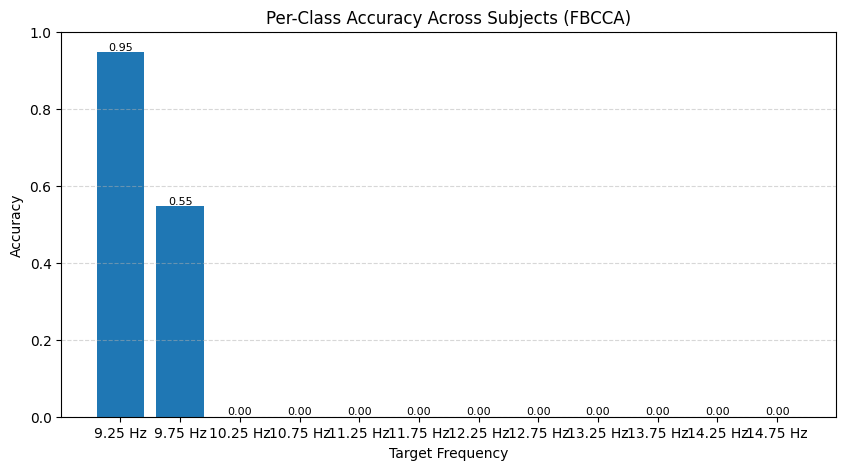

In [ ]:

TARGET_FREQS = np.array(TARGET_FREQS)
mean_per_class = np.array(mean_per_class)
std_per_class = np.array(std_per_class)

# Sort by frequency
sorted_idx = np.argsort(TARGET_FREQS)

TARGET_FREQS_sorted = TARGET_FREQS[sorted_idx]
mean_sorted = mean_per_class[sorted_idx]
std_sorted = std_per_class[sorted_idx]

# Plot
plt.figure(figsize=(10, 5))

x = np.arange(len(TARGET_FREQS_sorted))

bars = plt.bar(x, mean_sorted, capsize=5)

plt.xticks(x, [f"{f:.2f} Hz" for f in TARGET_FREQS_sorted])
plt.xlabel("Target Frequency")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy Across Subjects (FBCCA)")

plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.show()



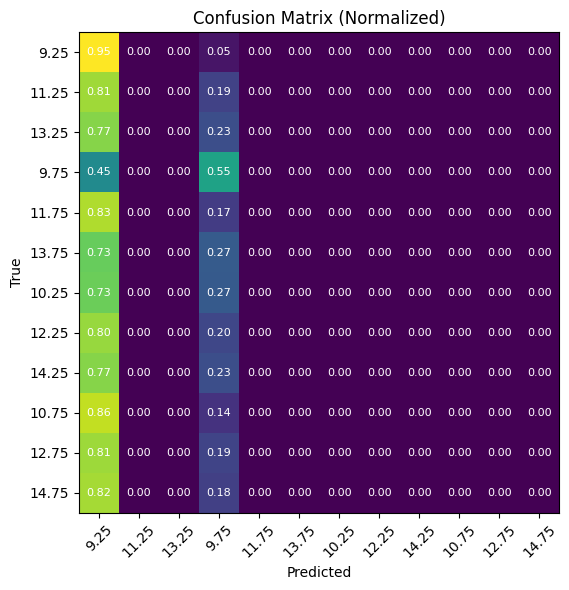

In [ ]:
# Ensure arrays
TARGET_FREQS = np.array(TARGET_FREQS)

# Sort indices
sorted_idx = np.argsort(TARGET_FREQS)

# Reorder everything consistently
TARGET_FREQS_sorted = TARGET_FREQS[sorted_idx]
norm_confusion_sorted = norm_confusion[sorted_idx][:, sorted_idx]


plt.figure(figsize=(8, 6))
plt.imshow(norm_confusion, cmap='viridis')

for i in range(norm_confusion.shape[0]):
    for j in range(norm_confusion.shape[1]):
        plt.text(j, i, f"{norm_confusion[i, j]:.2f}",
                 ha='center', va='center', color='white', fontsize=8)

plt.xticks(range(len(TARGET_FREQS)), [f"{f:.2f}" for f in TARGET_FREQS], rotation=45)
plt.yticks(range(len(TARGET_FREQS)), [f"{f:.2f}" for f in TARGET_FREQS])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Normalized)")

plt.tight_layout()
plt.show()
